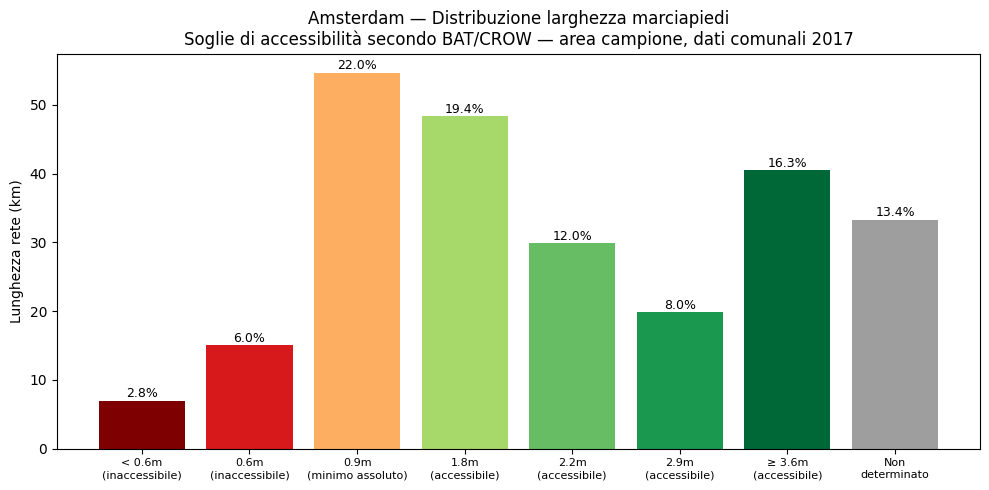

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Carica e riproietta
gdf = gpd.read_file(r'D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\voetpaden-breedte.json', on_invalid="ignore").set_crs(epsg=4326, allow_override=True)
gdf_rd = gdf.to_crs(epsg=28992)
gdf_rd['length_m'] = gdf_rd.geometry.length

order = ['Smaller dan 0.6m', '0.6m', '0.9m', '1.8m', '2.2m', '2.9m', '3.6m of breder', 'Nog onbepaald']
labels_chart = [
    '< 0.6m\n(inaccessibile)', '0.6m\n(inaccessibile)', '0.9m\n(minimo assoluto)',
    '1.8m\n(accessibile)', '2.2m\n(accessibile)', '2.9m\n(accessibile)',
    '≥ 3.6m\n(accessibile)', 'Non\ndeterminato'
]
colors = ['#7f0000', '#d7191c', '#fdae61', '#a6d96a', '#66bd63', '#1a9850', '#006837', '#9e9e9e']

# Statistica per lunghezza totale di rete, non per conteggio segmenti
stats_km = gdf_rd.groupby('ComfortLevel')['length_m'].sum().reindex(order) / 1000
pct = stats_km / stats_km.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels_chart, stats_km, color=colors)
ax.set_ylabel('Lunghezza rete (km)')
ax.set_title('Amsterdam — Distribuzione larghezza marciapiedi\nSoglie di accessibilità secondo BAT/CROW — area campione, dati comunali 2017')

for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{p:.1f}%', ha='center', fontsize=9)

plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(r'D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\distribuzione_comfortlevel.png', dpi=150)
plt.show()

In [3]:
import geopandas as gpd
import folium

# Carica (senza riprojezione: folium vuole lat/lon originali)
gdf = gpd.read_file(r'D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\voetpaden-breedte.json', on_invalid="ignore").set_crs(epsg=4326, allow_override=True)

order = ['Smaller dan 0.6m','0.6m','0.9m','1.8m','2.2m','2.9m','3.6m of breder','Nog onbepaald']
colors = {
    'Smaller dan 0.6m': '#7f0000',
    '0.6m': '#d7191c',
    '0.9m': '#fdae61',
    '1.8m': '#a6d96a',
    '2.2m': '#66bd63',
    '2.9m': '#1a9850',
    '3.6m of breder': '#006837',
    'Nog onbepaald': '#9e9e9e',
}
labels_map = {
    'Smaller dan 0.6m': '< 0.6m — inaccessibile',
    '0.6m': '0.6m — inaccessibile',
    '0.9m': '0.9m — minimo assoluto (solo punti isolati)',
    '1.8m': '1.8m — accessibile',
    '2.2m': '2.2m — accessibile',
    '2.9m': '2.9m — accessibile',
    '3.6m of breder': '\u2265 3.6m — accessibile',
    'Nog onbepaald': 'Non determinato',
}

m = folium.Map(location=[52.3676, 4.9041], zoom_start=13, tiles=None)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}',
    attr='Esri, HERE, Garmin, FAO, NOAA, USGS',
    name='Base map',
    control=False
).add_to(m)

for cat in order:
    fg = folium.FeatureGroup(name=f"{labels_map[cat]} ({(gdf['ComfortLevel']==cat).sum()})")
    sub = gdf[gdf['ComfortLevel']==cat]
    for _, row in sub.iterrows():
        coords = [(lat, lon) for lon, lat in row.geometry.coords]
        folium.PolyLine(
            coords, color=colors[cat], weight=3, opacity=0.85,
            popup=f"{row['Streetname']}<br>{labels_map[cat]}"
        ).add_to(fg)
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

title_html = '''
<div style="position: fixed; top: 10px; left: 50px; z-index:9999; background: white; padding: 10px 16px; border-radius: 6px; box-shadow: 0 1px 4px rgba(0,0,0,0.3); font-family: sans-serif; font-size: 13px;">
<b>Amsterdam — Accessibilità marciapiedi</b><br>
<span style="font-size:11px; color:#555;">Soglie BAT/CROW · Area campione, dati comunali 2017</span>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

m.save(r'D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\voetpaden_accessibilita.html')
print("Mappa salvata")

Mappa salvata
